# Airport and Year Comparison

This notebook compares all merged airport-year datasets. It is designed to complement the detailed single-dataset notebooks without repeating every chart nine times.

Files are loaded one at a time. Only compact summaries and reproducible samples are kept, which limits memory use while still revealing differences across airports and years.

In [1]:
from pathlib import Path
import gc
import sys

EDA_DIR = Path.cwd() if (Path.cwd() / "config.py").exists() else Path.cwd() / "eda"
if str(EDA_DIR) not in sys.path:
    sys.path.insert(0, str(EDA_DIR))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from config import FIGURE_DPI, RANDOM_STATE
from eda_utils import (
    TARGET_COLUMNS,
    add_eda_columns,
    available_merged_files,
    load_merged,
    safe_sample,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = FIGURE_DPI
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

files = available_merged_files()
print(f"Found {len(files)} merged airport-year files:")
for path in files:
    print(f"  {path.name}")

Found 9 merged airport-year files:
  ATL_2019.csv
  ATL_2023.csv
  ATL_2024.csv
  JFK_2019.csv
  JFK_2023.csv
  JFK_2024.csv
  ORD_2019.csv
  ORD_2023.csv
  ORD_2024.csv


## Build comparison summaries

For each file, this step records flight counts, target rates, category counts, missingness, typical weather and traffic, and source-record ages. It also creates monthly and hourly summaries plus a small sample for distribution plots.

In [2]:
summary_rows = []
monthly_parts = []
hourly_parts = []
sample_parts = []

for path in files:
    airport, year_text = path.stem.split("_")
    year = int(year_text)
    data = add_eda_columns(load_merged(airport, year))

    summary_rows.append(
        {
            "Airport": airport,
            "Year": year,
            "Flights": len(data),
            "FirstDate": data["DATE"].min(),
            "LastDate": data["DATE"].max(),
            "DepartureDelayRate": data["DepDel15"].mean() * 100,
            "ArrivalDelayRate": data["ArrDel15"].mean() * 100,
            "Airlines": data["Reporting_Airline"].nunique(),
            "Destinations": data["Dest"].nunique(),
            "MissingCellsPercent": data.isna().mean().mean() * 100,
            "ExactDuplicateRows": int(data.duplicated().sum()),
            "MedianScheduledTraffic": data["ASPM_Total_Scheduled_Traffic"].median(),
            "MedianVisibility": data["HourlyVisibility"].median(),
            "AdverseWeatherRate": data["AdverseWeather"].mean() * 100,
            "MedianASPMage": data["ASPM_AGE_MINUTES"].median(),
            "MedianNOAAage": data["NOAA_AGE_MINUTES"].median(),
        }
    )

    monthly = (
        data.groupby("Month")[list(TARGET_COLUMNS)]
        .mean()
        .mul(100)
        .reset_index()
    )
    monthly["Airport"] = airport
    monthly["Year"] = year
    monthly_parts.append(monthly)

    hourly = (
        data.groupby("ScheduledDepartureHour")[list(TARGET_COLUMNS)]
        .mean()
        .mul(100)
        .reset_index()
    )
    hourly["Airport"] = airport
    hourly["Year"] = year
    hourly_parts.append(hourly)

    sample = safe_sample(data, 5_000, RANDOM_STATE).copy()
    sample["Airport"] = airport
    sample["DatasetYear"] = year
    sample_parts.append(
        sample[
            [
                "Airport",
                "DatasetYear",
                "ASPM_Total_Scheduled_Traffic",
                "HourlyVisibility",
                "HourlyWindSpeed",
                "ASPM_AGE_MINUTES",
                "NOAA_AGE_MINUTES",
            ]
        ]
    )

    del data
    gc.collect()

summary = pd.DataFrame(summary_rows).sort_values(["Airport", "Year"])
monthly_all = pd.concat(monthly_parts, ignore_index=True)
hourly_all = pd.concat(hourly_parts, ignore_index=True)
plot_samples = pd.concat(sample_parts, ignore_index=True)

display(summary)

,Airport,Year,Flights,FirstDate,LastDate,DepartureDelayRate,ArrivalDelayRate,Airlines,Destinations,MissingCellsPercent,ExactDuplicateRows,MedianScheduledTraffic,MedianVisibility,AdverseWeatherRate,MedianASPMage,MedianNOAAage
0,ATL,2019,391701,2019-01-01 05:45:00,2019-12-31 22:56:00,16.755,15.706,15,168,0.000,0,147.000,10.000,9.607,90.000,25.000
1,ATL,2023,332935,2023-01-01 05:00:00,2023-12-31 23:00:00,20.621,19.461,13,153,0.000,0,117.000,10.000,10.031,89.000,23.000
2,ATL,2024,337662,2024-01-01 05:21:00,2024-12-31 22:59:00,19.692,19.854,13,157,0.001,0,123.000,10.000,9.399,90.000,23.000
3,JFK,2019,124759,2019-01-01 05:00:00,2019-12-31 23:58:00,18.873,20.168,10,71,0.000,0,66.000,10.000,13.032,90.000,24.000
4,JFK,2023,129620,2023-01-01 05:10:00,2023-12-31 23:25:00,22.994,23.157,8,71,0.000,0,69.000,10.000,10.711,90.000,24.000
5,JFK,2024,120770,2024-01-01 05:30:00,2024-12-31 23:50:00,20.168,21.056,9,74,0.058,0,66.000,10.000,10.315,90.000,22.000
6,ORD,2019,328129,2019-01-01 05:00:00,2019-12-31 22:42:00,22.465,25.716,13,186,0.003,0,147.000,10.000,12.506,86.000,24.000
7,ORD,2023,255071,2023-01-01 05:00:00,2023-12-31 23:00:00,19.941,22.021,12,166,0.000,0,126.000,10.000,11.711,89.000,24.000
8,ORD,2024,275505,2024-01-01 05:00:00,2024-12-31 21:54:00,22.102,23.693,12,163,0.035,0,135.000,10.000,9.609,85.000,23.000


## Dataset size and basic coverage

Flight counts vary substantially by airport and year. This matters when comparing raw counts and when deciding how to partition data for training, development, and final testing.

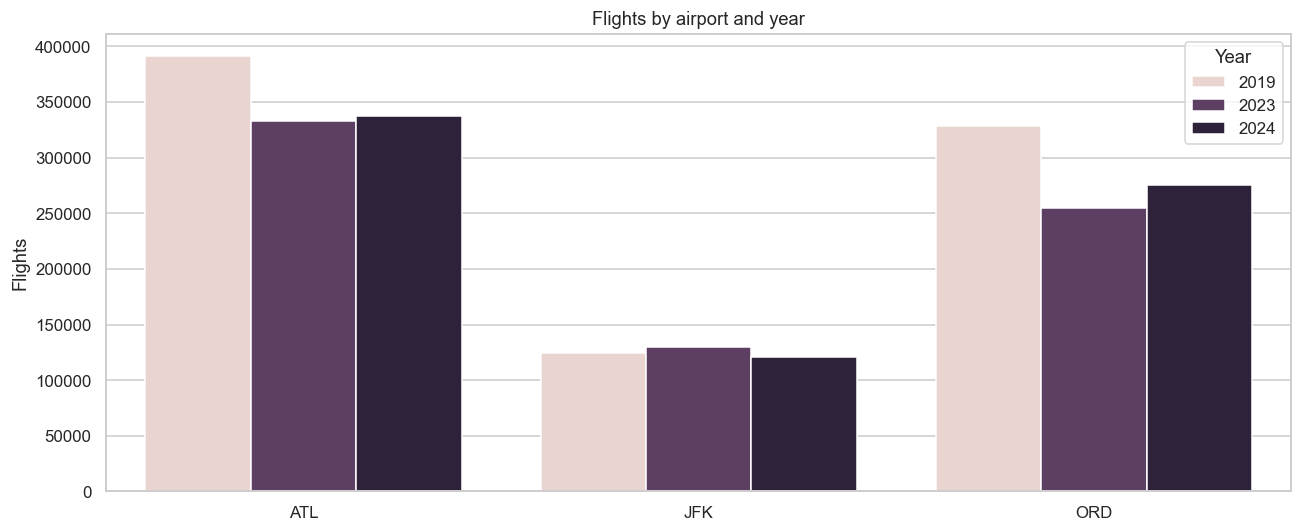

In [3]:
plt.figure(figsize=(12, 5))
sns.barplot(data=summary, x="Airport", y="Flights", hue="Year")
plt.title("Flights by airport and year")
plt.xlabel("")
plt.ylabel("Flights")
plt.tight_layout()
plt.show()

## Departure- and arrival-delay rates

These comparisons establish whether target balance changes by airport or year. Models should be evaluated separately enough to reveal these differences.

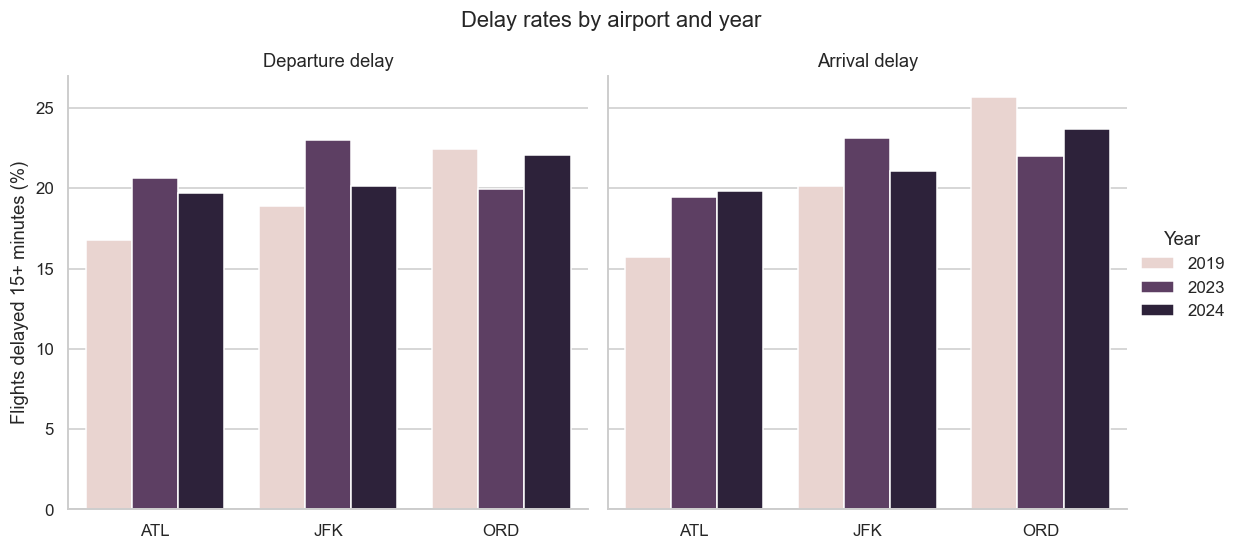

In [4]:
delay_summary = summary.melt(
    id_vars=["Airport", "Year"],
    value_vars=["DepartureDelayRate", "ArrivalDelayRate"],
    var_name="Target",
    value_name="DelayRate",
)
delay_summary["Target"] = delay_summary["Target"].map(
    {
        "DepartureDelayRate": "Departure delay",
        "ArrivalDelayRate": "Arrival delay",
    }
)

g = sns.catplot(
    data=delay_summary,
    x="Airport",
    y="DelayRate",
    hue="Year",
    col="Target",
    kind="bar",
    height=5,
    aspect=1.05,
    sharey=True,
)
g.set_axis_labels("", "Flights delayed 15+ minutes (%)")
g.set_titles("{col_name}")
g.figure.suptitle("Delay rates by airport and year", y=1.04)
plt.show()

## Delay-rate heatmaps

The heatmaps make the airport-year differences easy to scan. Each cell is the percentage of flights classified as delayed.

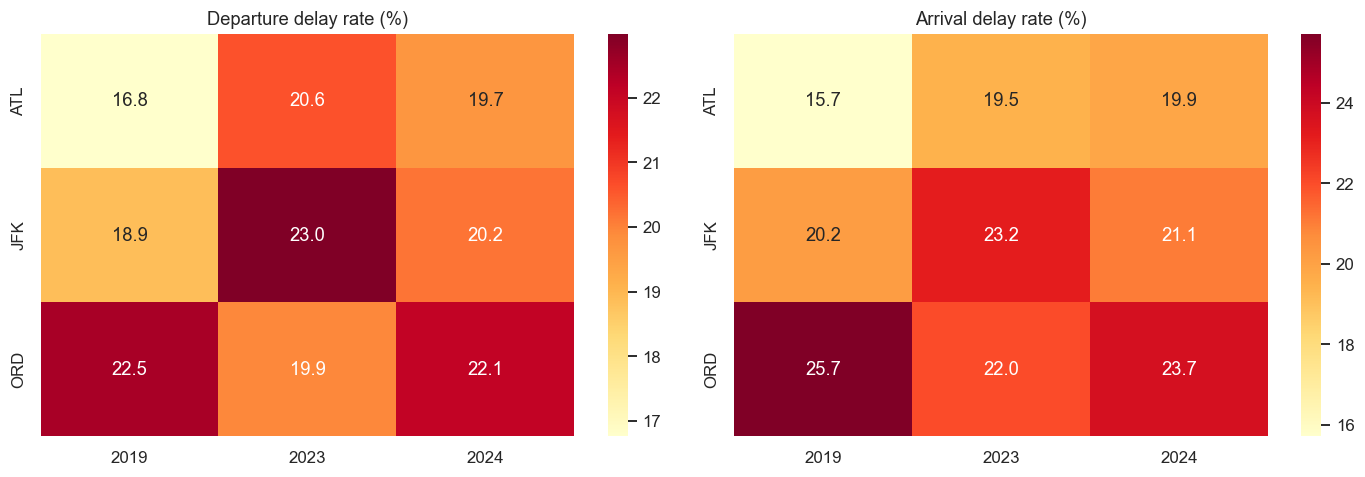

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for target, title, axis in [
    ("DepartureDelayRate", "Departure delay rate (%)", axes[0]),
    ("ArrivalDelayRate", "Arrival delay rate (%)", axes[1]),
]:
    table = summary.pivot(index="Airport", columns="Year", values=target)
    sns.heatmap(table, annot=True, fmt=".1f", cmap="YlOrRd", ax=axis)
    axis.set_title(title)
    axis.set_xlabel("")
    axis.set_ylabel("")
plt.tight_layout()
plt.show()

## Monthly patterns

Each row shows one airport, with separate lines for the three years. This view checks whether seasonality is consistent or changes across the pre- and post-pandemic periods.

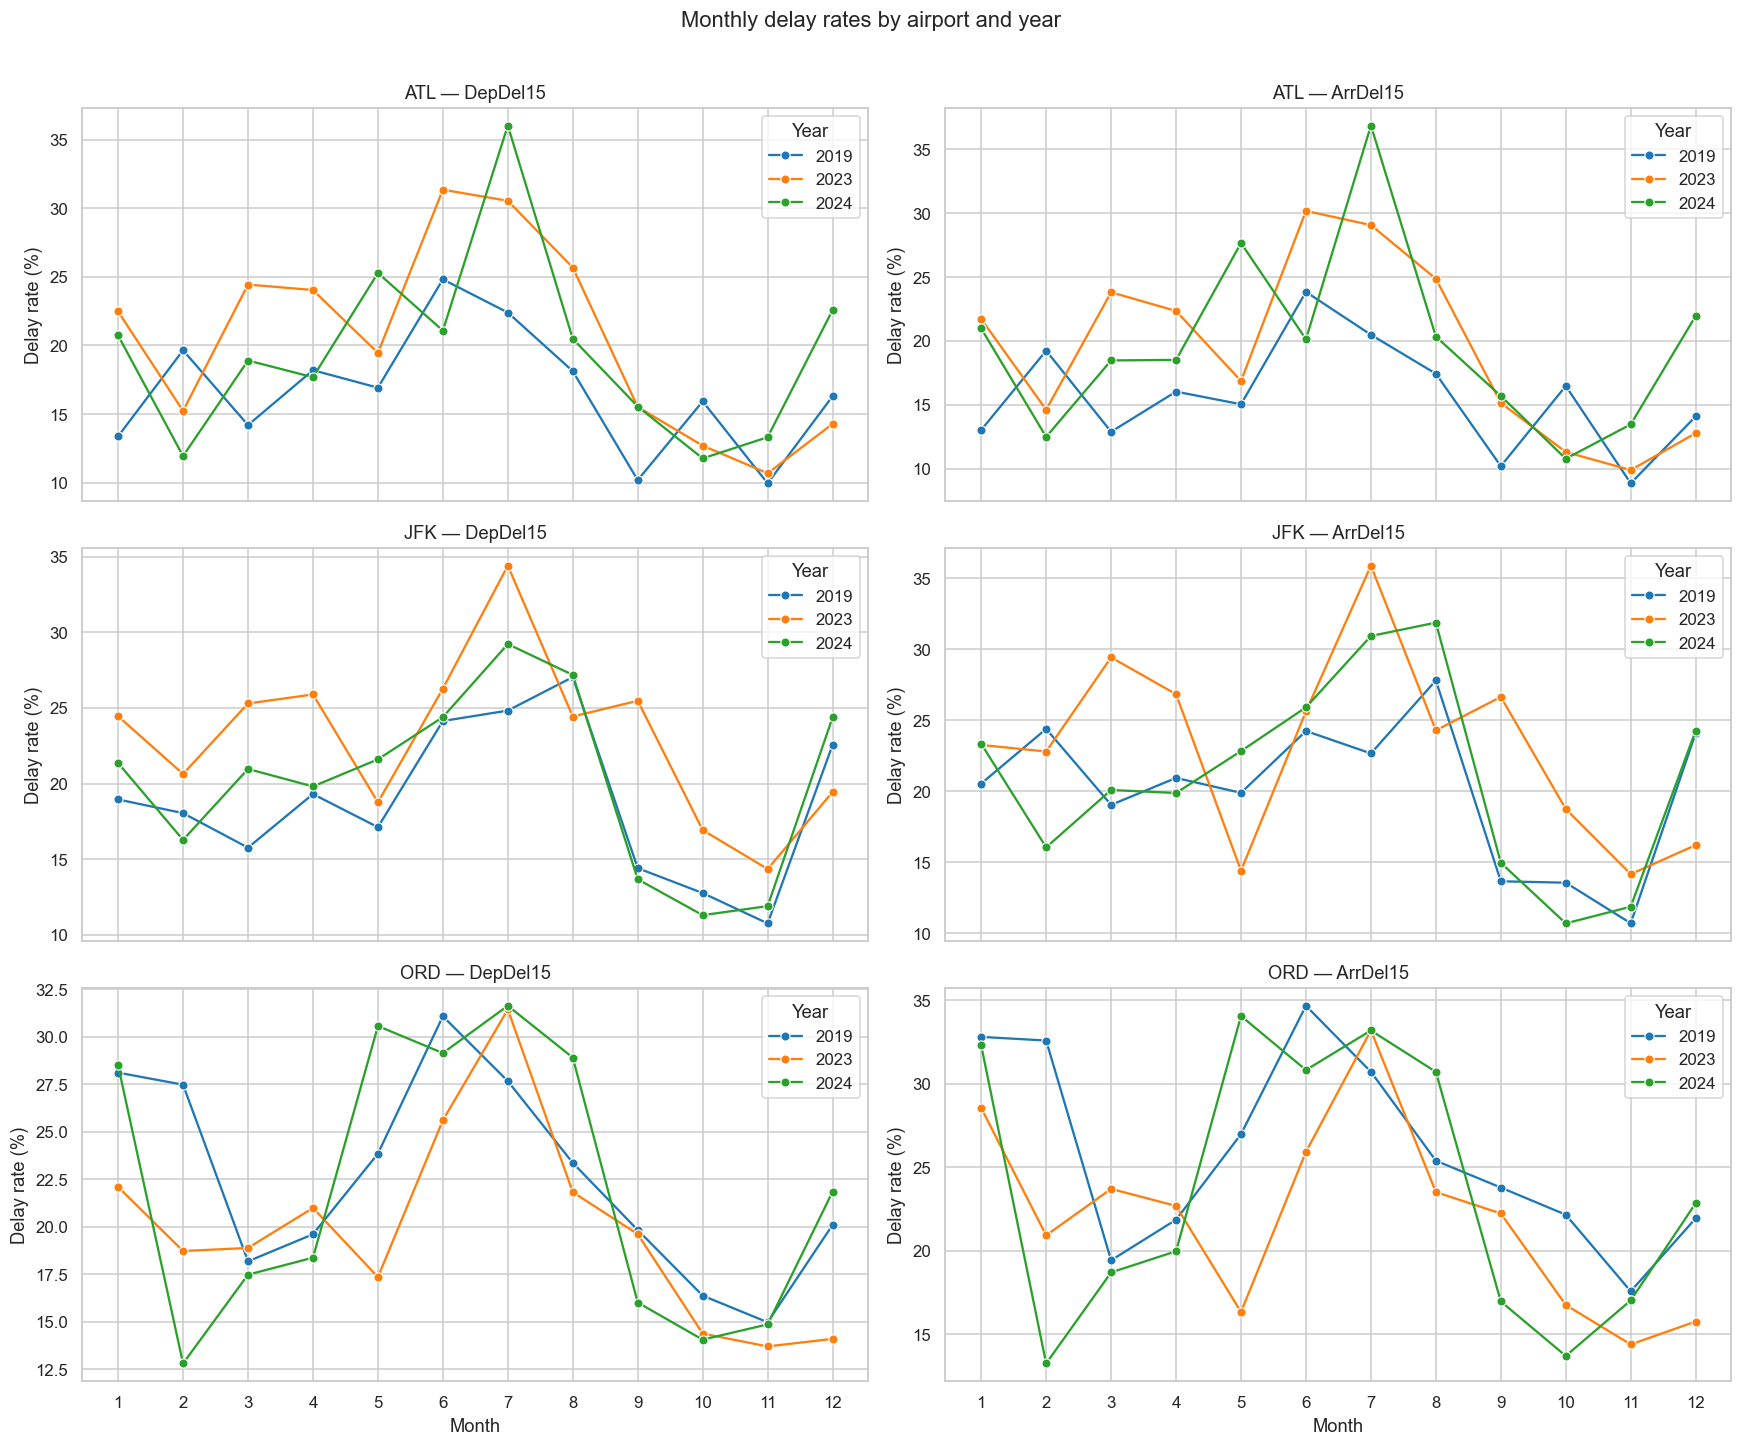

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(16, 13), sharex=True)
for row, airport in enumerate(["ATL", "JFK", "ORD"]):
    airport_data = monthly_all.loc[monthly_all["Airport"] == airport]
    for column, target in enumerate(TARGET_COLUMNS):
        sns.lineplot(
            data=airport_data,
            x="Month",
            y=target,
            hue="Year",
            marker="o",
            palette="tab10",
            ax=axes[row, column],
        )
        axes[row, column].set_title(f"{airport} — {target}")
        axes[row, column].set_xlabel("Month")
        axes[row, column].set_ylabel("Delay rate (%)")
        axes[row, column].set_xticks(range(1, 13))
plt.suptitle("Monthly delay rates by airport and year", y=1.01)
plt.tight_layout()
plt.show()

## Scheduled-hour patterns

Delay risk often changes across the operating day. Comparing these curves shows whether the same daily build-up appears at all three airports and in all three years.

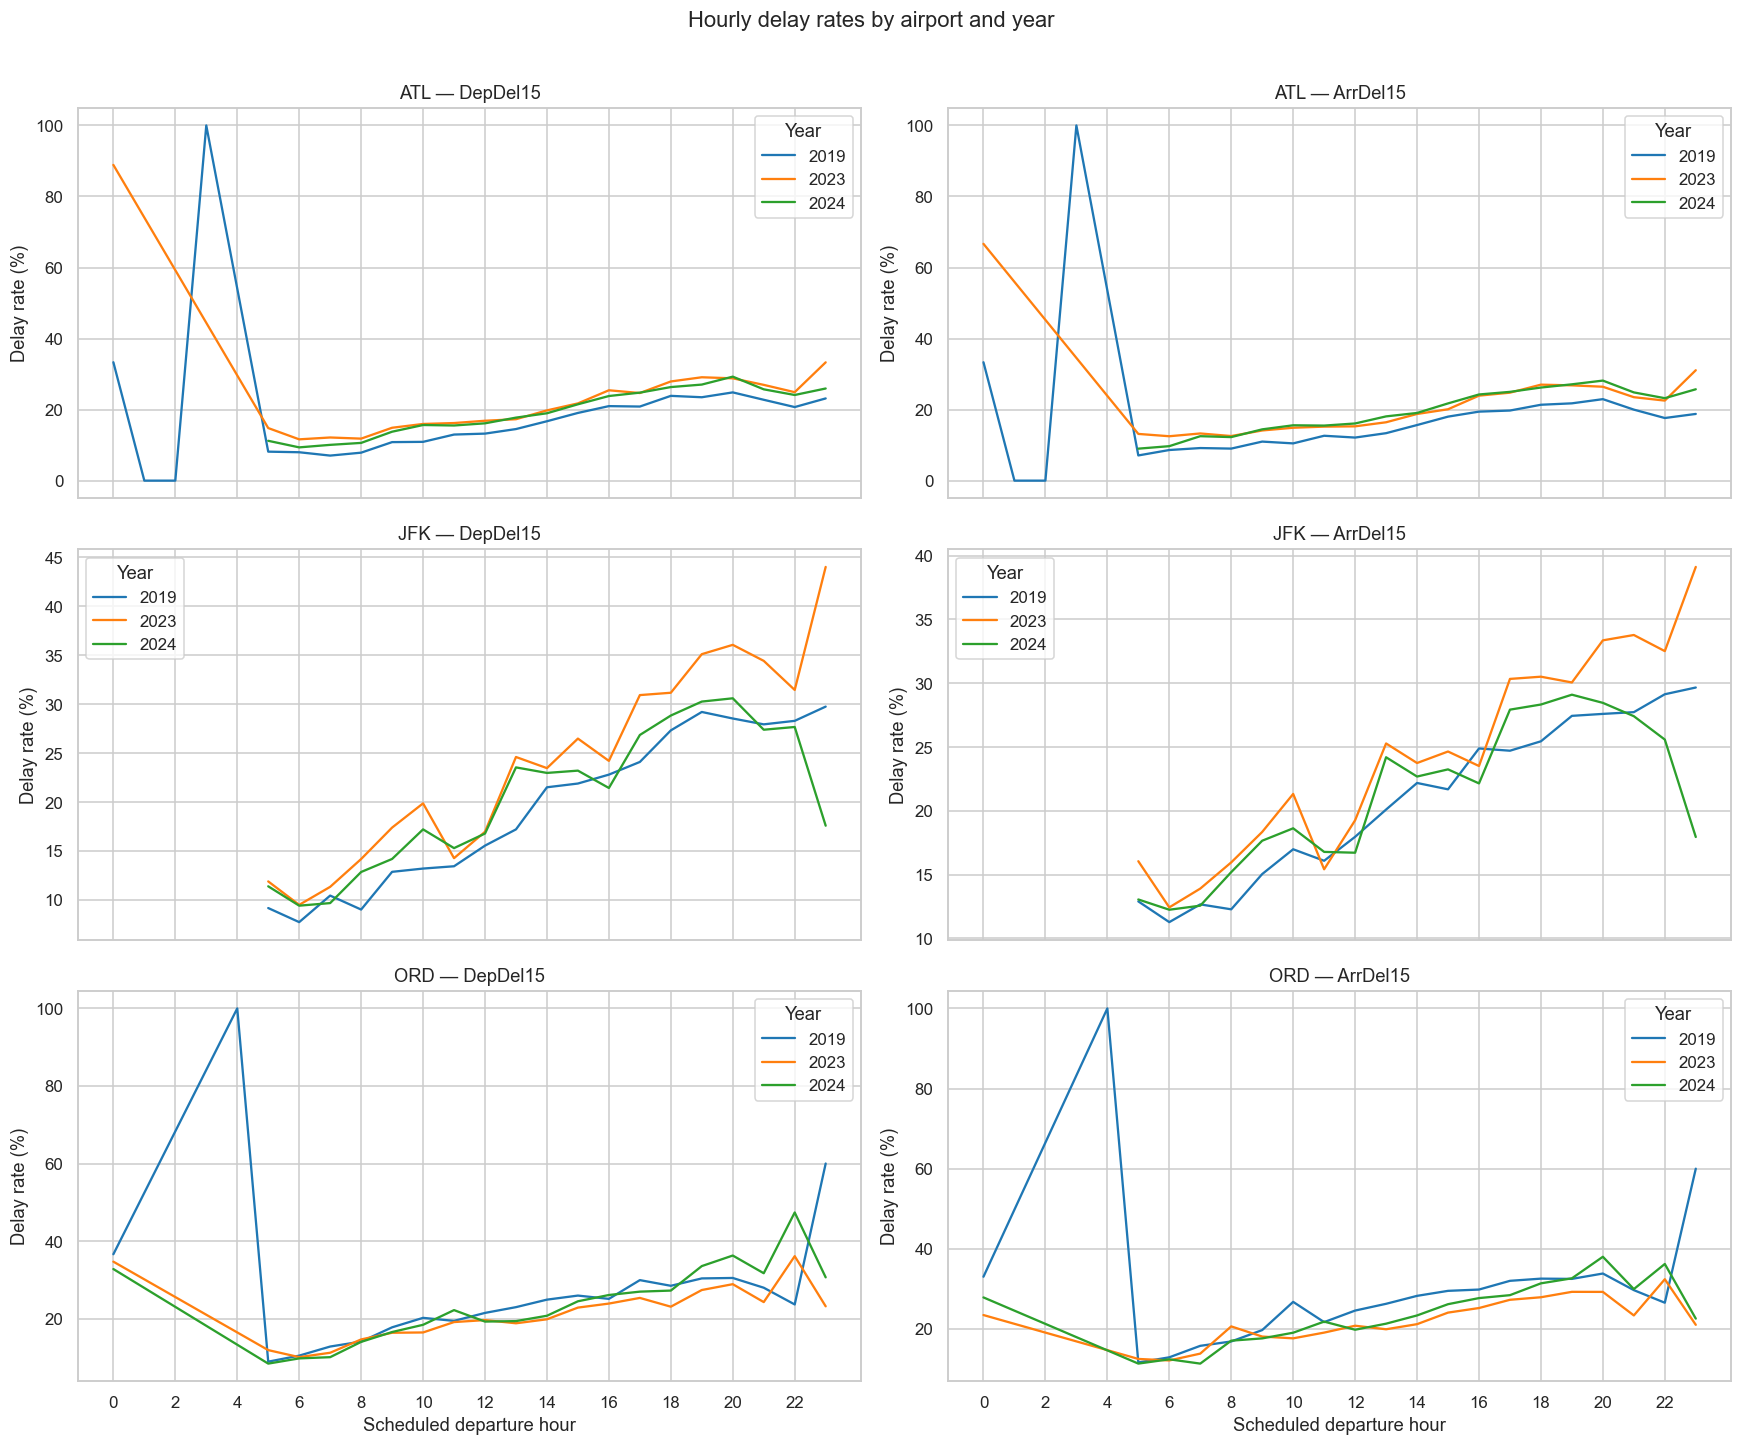

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(16, 13), sharex=True)
for row, airport in enumerate(["ATL", "JFK", "ORD"]):
    airport_data = hourly_all.loc[hourly_all["Airport"] == airport]
    for column, target in enumerate(TARGET_COLUMNS):
        sns.lineplot(
            data=airport_data,
            x="ScheduledDepartureHour",
            y=target,
            hue="Year",
            palette="tab10",
            ax=axes[row, column],
        )
        axes[row, column].set_title(f"{airport} — {target}")
        axes[row, column].set_xlabel("Scheduled departure hour")
        axes[row, column].set_ylabel("Delay rate (%)")
        axes[row, column].set_xticks(range(0, 24, 2))
plt.suptitle("Hourly delay rates by airport and year", y=1.01)
plt.tight_layout()
plt.show()

## Airport traffic distributions

These sampled distributions compare the ASPM scheduled-traffic range across airports and years. The samples are used only to keep the chart responsive; the summary statistics above use every row.

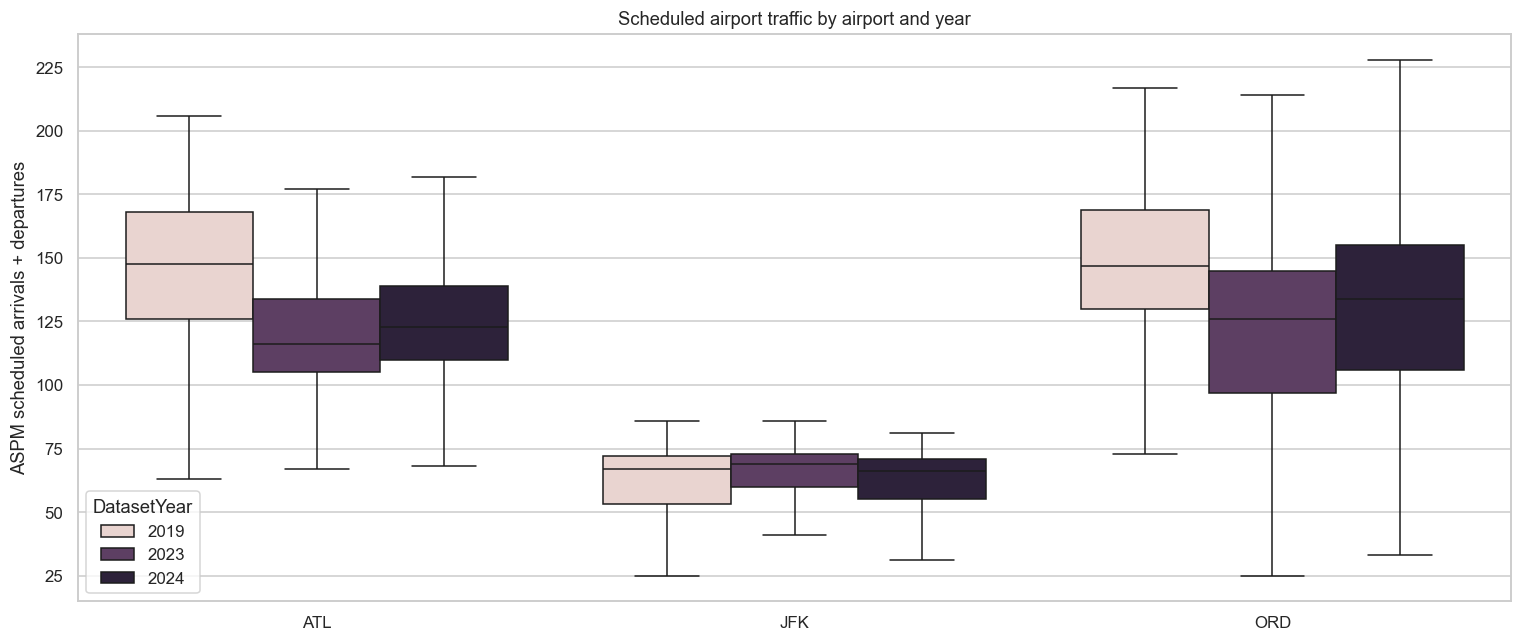

In [8]:
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=plot_samples,
    x="Airport",
    y="ASPM_Total_Scheduled_Traffic",
    hue="DatasetYear",
    showfliers=False,
)
plt.title("Scheduled airport traffic by airport and year")
plt.xlabel("")
plt.ylabel("ASPM scheduled arrivals + departures")
plt.tight_layout()
plt.show()

## Weather and source-match differences

Visibility and source ages can differ by airport and year because of local weather and reporting schedules. Large differences should be considered when interpreting models and checking merge quality.

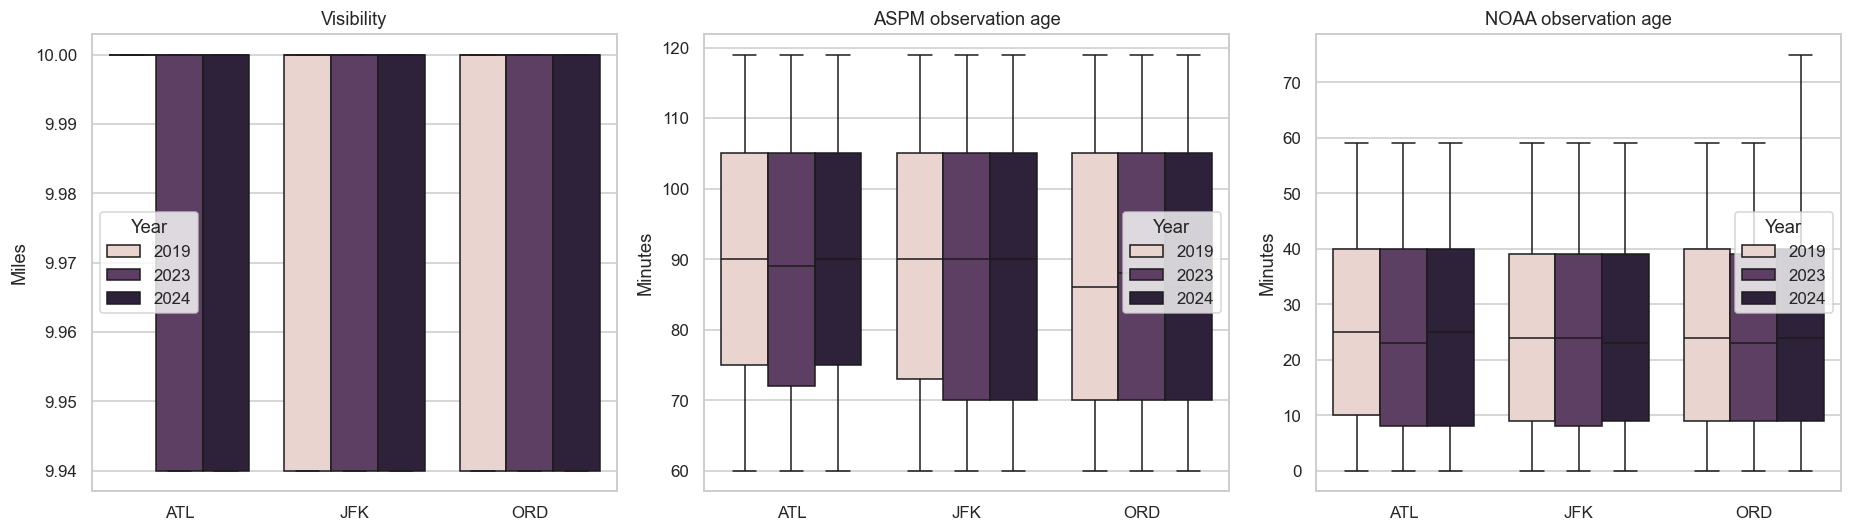

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.boxplot(
    data=plot_samples,
    x="Airport",
    y="HourlyVisibility",
    hue="DatasetYear",
    showfliers=False,
    ax=axes[0],
)
axes[0].set_title("Visibility")
axes[0].set_xlabel("")
axes[0].set_ylabel("Miles")

sns.boxplot(
    data=plot_samples,
    x="Airport",
    y="ASPM_AGE_MINUTES",
    hue="DatasetYear",
    showfliers=False,
    ax=axes[1],
)
axes[1].set_title("ASPM observation age")
axes[1].set_xlabel("")
axes[1].set_ylabel("Minutes")

sns.boxplot(
    data=plot_samples,
    x="Airport",
    y="NOAA_AGE_MINUTES",
    hue="DatasetYear",
    showfliers=False,
    ax=axes[2],
)
axes[2].set_title("NOAA observation age")
axes[2].set_xlabel("")
axes[2].set_ylabel("Minutes")

for axis in axes:
    legend = axis.get_legend()
    if legend is not None:
        legend.set_title("Year")

plt.tight_layout()
plt.show()

## Comparison checklist

Use the comparison results to document:

- changes in class balance across airports or years;
- differences in monthly and hourly delay patterns;
- airports with substantially different traffic or weather ranges;
- unexpected missingness, duplicates, or source-match ages;
- patterns that should be shown in the final capstone report.

These comparisons help decide whether one shared model, airport-specific models, or both should be evaluated later. That decision should follow the evidence rather than be assumed during EDA.